# Table of Contents
- Understanding Gradient Discent
- Linear Regression from Scratch
- Linear Regression using sklearn
- Regression Metrics


# Understanding Gradient Discent

#### N.B. More in the end of the notebook

Gradient discent is an optimization algorithm to find the minimum of a function.

Start with a random point on the function and move in the negative direction of the gradient of the function to reach the local/global minima.


![](https://techtodays.weebly.com/uploads/1/4/8/0/148068501/783698267_orig.PNG)

# Linerar Regression from Scratch

Let’s build **Linear Regression from scratch using NumPy**, step by step, in a beginner-friendly way. No shortcuts, no libraries like sklearn — just core understanding.

---

#### 1. What is Linear Regression?

We try to fit a straight line:

[
y = wx + b
]

* `w` = slope (weight)
* `b` = intercept (bias)
* Goal → find `w` and `b` that best fit the data

---

#### 2. Import & Create Dataset

```python
import numpy as np
import matplotlib.pyplot as plt

# simple dataset
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

# visualize
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Data")
plt.show()
```

---

#### 3. Initialize Parameters

```python
w = 0.0   # slope
b = 0.0   # intercept
```

---

#### 4. Define Loss Function (MSE)

We measure error using **Mean Squared Error**:
$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2
$

```python
def compute_loss(X, y, w, b):
    n = len(X)
    y_pred = w * X + b
    loss = np.sum((y - y_pred) ** 2) / n
    return loss
```

---

#### 5. Gradient Descent (Core Learning)

We update `w` and `b` step by step:

$
w := w - \alpha \frac{\partial J}{\partial w}, \quad b := b - \alpha \frac{\partial J}{\partial b}
$

```python
def compute_gradients(X, y, w, b):
    n = len(X)
    y_pred = w * X + b
    
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    return dw, db
```

---

#### 6. Training Loop

```python
learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    dw, db = compute_gradients(X, y, w, b)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if i % 100 == 0:
        loss = compute_loss(X, y, w, b)
        print(f"Epoch {i}, Loss: {loss:.4f}")
```

---

#### 7. Final Result

```python
print("Final parameters:")
print("w =", w)
print("b =", b)
```

---

#### 8. Plot the Regression Line

```python
y_pred = w * X + b

plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color='red', label="Fitted Line")
plt.legend()
plt.show()
```

---

#### Intuition Recap

* Start with random `w`, `b`
* Predict → calculate error
* Adjust parameters using gradients
* Repeat until error is small

---



In [ ]:
import numpy as np

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None
        self.loss_history = []

    def _initialize_params(self):
        self.w = 0.0
        self.b = 0.0

    def _compute_loss(self, X, y):
        n = len(X)
        y_pred = self.w * X + self.b
        loss = np.sum((y - y_pred) ** 2) / n
        return loss

    def _compute_gradients(self, X, y):
        n = len(X)
        y_pred = self.w * X + self.b

        dw = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        return dw, db

    def fit(self, X, y, verbose=False):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        self._initialize_params()

        for i in range(self.epochs):
            dw, db = self._compute_gradients(X, y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            loss = self._compute_loss(X, y)
            self.loss_history.append(loss)

            if verbose and i % 100 == 0:
                print(f"Epoch {i}, Loss: {loss:.4f}")

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.w * X + self.b

    def get_params(self):
        return {"w": self.w, "b": self.b}

Epoch 0, Loss: 24.7472
Epoch 100, Loss: 3.3535
Epoch 200, Loss: 3.3199
Epoch 300, Loss: 3.3076
Epoch 400, Loss: 3.3031
Epoch 500, Loss: 3.3015
Epoch 600, Loss: 3.3009
Epoch 700, Loss: 3.3007
Epoch 800, Loss: 3.3006
Epoch 900, Loss: 3.3006
{'w': np.float64(2.384755780111989), 'b': np.float64(1.1240562502474123)}


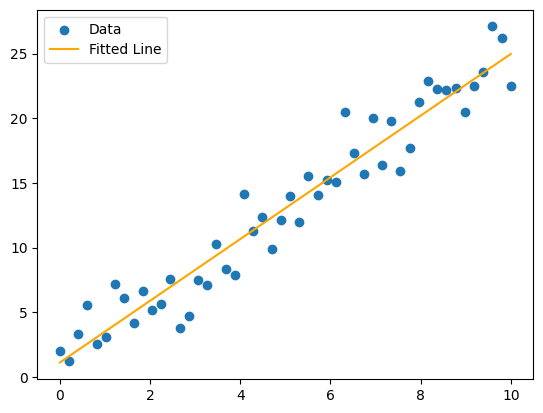

In [ ]:
import matplotlib.pyplot as plt

# data
# X = np.array([1, 2, 3, 4, 5])
# y = np.array([2, 4, 5, 4, 5])

np.random.seed(42)

# generate data
X = np.linspace(0, 10, 50)
true_w = 2.5
true_b = 1.0

noise = np.random.randn(50) * 2
y = true_w * X + true_b + noise

# model
model = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

# train
model.fit(X, y, verbose=True)

# predict
y_pred = model.predict(X)

# params
print(model.get_params())

# plot
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, label="Fitted Line", color="orange")
plt.legend()
plt.show()

# Linear Regression using Scikit Learn

Slope (w): [2.32586432]
Intercept (b): [1.94107486]
MSE  : 1.63
RMSE : 1.28
MAE  : 1.03
R²   : 0.9456


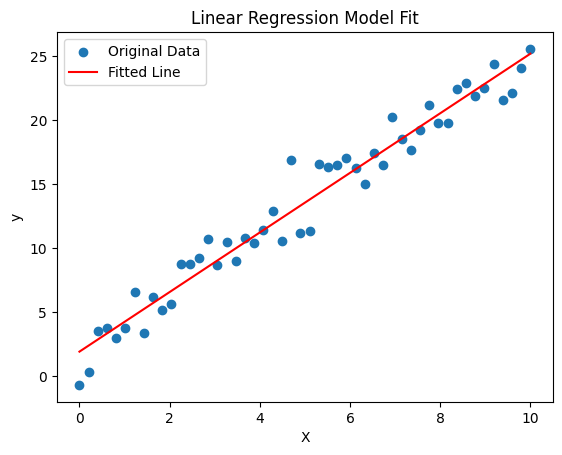

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. GENERATE RANDOM DATA
# =========================
# generate data
X = np.linspace(0, 10, 50)
true_w = 2.5
true_b = 1.0

noise = np.random.randn(50) * 2
y = true_w * X + true_b + noise

X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

# =========================
# 2. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. TRAIN MODEL
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# 4. PREDICT
# =========================
y_pred = model.predict(X_test)

# =========================
# 5. METRICS
# =========================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Slope (w):", model.coef_[0])
print("Intercept (b):", model.intercept_)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

# =========================
# 6. PLOT
# =========================
# Plot the original full dataset
plt.scatter(X, y, label="Original Data")

# Generate predictions for the entire dataset (X) to plot the regression line over the full range
y_full_pred = model.predict(X)

# Sort X and its predictions to ensure the line is drawn correctly
sorted_indices = np.argsort(X.flatten())
X_sorted_full = X[sorted_indices]
y_full_pred_sorted = y_full_pred[sorted_indices]

# Plot the fitted line using predictions on the full dataset
plt.plot(X_sorted_full, y_full_pred_sorted, color='red', label="Fitted Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Model Fit")
plt.legend()
plt.show()

# Model Evaluation: Regression Metrics

A model evaluation metric is a numerical way to measure how good a machine learning model is at making predictions.

👉 In simple terms:

It tells you how **wrong** or **right** your model is.


![](https://miro.medium.com/1*5fnmYVHLTC8mGxybHm4XkA.png)

![](https://backend.aionlinecourse.com/uploads/tutorials/2019/05/29_1_Evaluating_Regression_Performance.jpg)


📉 MSE
penalizes big errors heavily
sensitive to outliers


📏 RMSE
same as MSE but in real units
more interpretable


📌 MAE
average absolute error
most intuitive (“off by ~X units”)


📊 R²
how good model is compared to baseline mean prediction


🔥 Quick intuition example

If:

- MAE = 2.5 → model is off by ~2.5 units on average
- RMSE = 3.8 → some big errors exist
- R² = 0.9 → very good fit

![](https://b3252691.smushcdn.com/3252691/wp-content/uploads/2026/02/ai_64-1536x864.png?lossy=2&strip=1&webp=1)


### Choosing the right metric


- **MAE**: When you care about absolute errors (robust to outliers).
- **MSE / RMSE**: When large errors are more serious (penalizes big mistakes).
- **R²**: When you want to measure overall **goodness of fit**.

✅ In practice:
- Use **MAE or RMSE** for error magnitude.
- Use **R²** for interpretability.
- Compare multiple metrics to make a decision.


# Project: Boston House Price Prediction

### Data Information
Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. Detailed attribute information can be found below-

Attribute Information (in order):

- `CRIM:` per capita crime rate by town
- `ZN:` proportion of residential land zoned for lots over 25,000 sq.ft.
- `INDUS:` proportion of non-retail business acres per town
- `CHAS:` Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- `NOX:` nitric oxides concentration (parts per 10 million)
- `RM:` average number of rooms per dwelling
- `AGE:` proportion of owner-occupied units built prior to 1940
- `DIS:` weighted distances to five Boston employment centres
- `RAD:` index of accessibility to radial highways
- `TAX:` full-value property-tax rate per 10,000 dollars
- `PTRATIO:` pupil-teacher ratio by town
- `B:` (Bk - 0.63)^2 where Bk is the proportion of blacks by town
- `LSTAT:` %lower status of the population
- `MEDV:` Median value of owner-occupied homes in 1000 dollars.

---

🎯 Label (Target Variable)

MEDV:	Median house price (in $1000s)

👉 This is what the model tries to predict

Example:

MEDV = 25 → house price ≈ $25,000

## ✅ Simple 1-Feature Linear Regression + Plot

Let’s use **`RM` (average number of rooms)** since it has a strong relationship with house price.

---

## 🧠 Intuition (this is the important part)

* Each point = a house
* X-axis = number of rooms
* Y-axis = price

👉 The line:

```
Price = m * RM + c
```

* **m (slope)** → how much price increases per extra room
* **c (intercept)** → base price when RM = 0 (not realistic, but mathematically needed)

---

## 🔥 What you’ll observe

* Clear **positive relationship** (more rooms → higher price)
* Points won’t perfectly lie on the line → real-world noise
* R² will be decent but not perfect → because we’re ignoring other features



MAE: 4.4783
R2 : 0.3708

Model Equation:
Price = 9.35 * RM + -36.25


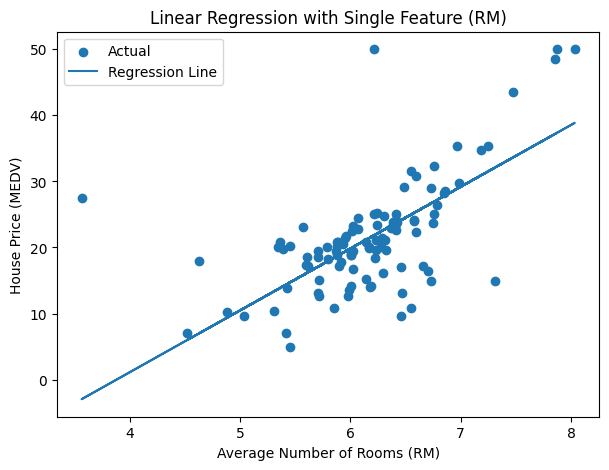

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset (fixed deprecation)
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df = pd.read_csv(data_url, sep=r"\s+", names=columns)

# ----------------------------
# 1. Use SINGLE feature
# ----------------------------
X = df[['RM']]     # only one feature
y = df['MEDV']     # target

# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Train Model
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ----------------------------
# 4. Predictions
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")

# ----------------------------
# 6. Line Equation
# ----------------------------
print(f"\nModel Equation:")
print(f"Price = {model.coef_[0]:.2f} * RM + {model.intercept_:.2f}")

# ----------------------------
# 7. Visualization
# ----------------------------
plt.figure(figsize=(7,5))

# scatter plot (actual data)
plt.scatter(X_test, y_test, label="Actual")

# regression line
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("Linear Regression with Single Feature (RM)")
plt.legend()

plt.show()

## Using All Features in Linear Regression

When you use **all features** instead of just one:

### 🔹 Model changes from line → hyperplane

* Single feature:

  ```
  y = m x + c   → straight line
  or,
  y = wx + b
  ```
* Multiple features:

  ```
  y = w1x1 + w2x2 + ... + wnxn + b
  ```

👉 Now it’s no longer a 2D line — it becomes a **hyperplane in higher dimensions**

---

#### 🔹 Interpretation becomes harder

* With one feature (e.g., RM), you can clearly see:

  > “More rooms → higher price”
* With many features:

  * Each coefficient shows *partial impact*
  * But features interact → intuition is less visual

---

#### 🔹 Performance usually improves

* More features = more information
* Typically:

  * ↓ Error (MAE, MSE)
  * ↑ R² score

⚠️ But only if features are meaningful

---

#### 🔹 Risk of overfitting

* Too many features → model may memorize noise
* Especially if:

  * dataset is small
  * features are irrelevant

👉 Solution:

* Train/test split ✅
* Cross-validation ✅
* Regularization (Ridge/Lasso) ✅

---

#### 🔹 Feature scaling may matter

* LinearRegression itself doesn’t require scaling
* But scaling helps:

  * interpret coefficients
  * use regularized models

---

#### 🔹 Multicollinearity issue

* Some features may be highly correlated (e.g., TAX & RAD)
* This can:

  * distort coefficients
  * reduce interpretability

---

#### 🔹 Practical takeaway

* Start with **1 feature → build intuition**
* Then move to **all features → improve performance**
* Then refine with:

  * feature selection
  * regularization


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df = pd.read_csv(data_url, sep=r"\s+", names=columns)

df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Evaluation Metrics:
MAE  : 3.1891
MSE  : 24.2911
RMSE : 4.9286
R2   : 0.6688


Feature Coefficient(W/m):
    Feature  Coefficient
5        RM     4.438835
3      CHAS     2.784438
8       RAD     0.262430
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
6       AGE    -0.006296
9       TAX    -0.010647
0      CRIM    -0.113056
12    LSTAT    -0.508571
10  PTRATIO    -0.915456
7       DIS    -1.447865
4       NOX   -17.202633


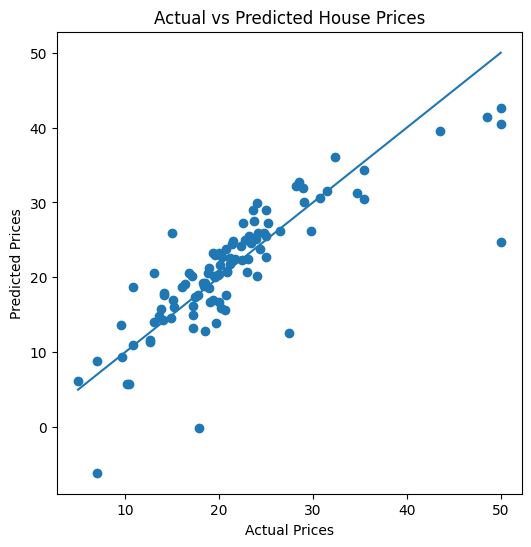

In [ ]:

# ----------------------------
# 1. Feature & Target Split
# ----------------------------
X = df.drop('MEDV', axis=1)   # features
y = df['MEDV']                # target

# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Model Training
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ----------------------------
# 4. Prediction
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation Metrics
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print()

# ----------------------------
# 6. Coefficients
# ----------------------------
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficient(W/m):")
print(coeff_df.sort_values(by='Coefficient', ascending=False))

# ----------------------------
# 7. Visualization
# ----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()])  # diagonal line
plt.show()

# Gradient Discent Explanation: In Progress

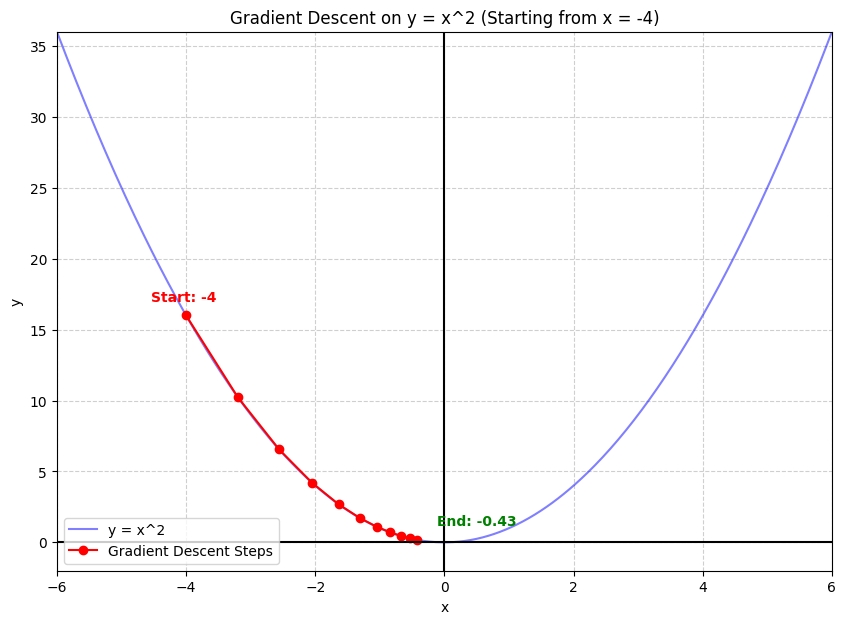

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function and its derivative (gradient)
def f(x):
    return x**2

def df(x):
    return 2*x

# 2. Set Parameters
x_start = -4
learning_rate = 0.1
iterations = 10

# 3. Perform Gradient Descent
x_steps = [x_start]
y_steps = [f(x_start)]
x_curr = x_start

for _ in range(iterations):
    gradient = df(x_curr)
    x_curr = x_curr - (learning_rate * gradient)
    x_steps.append(x_curr)
    y_steps.append(f(x_curr))

# 4. Generate Plot
x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 7))

# Plot the main curve
plt.plot(x_vals, y_vals, 'b-', label='y = x^2', alpha=0.5)

# Plot the descent path
plt.plot(x_steps, y_steps, 'ro-', label='Gradient Descent Steps', markersize=6)

# Setup 4-quadrant view
plt.axhline(0, color='black', linewidth=1.5) # X-axis
plt.axvline(0, color='black', linewidth=1.5) # Y-axis
plt.grid(True, linestyle='--', alpha=0.6)

# Annotations
plt.annotate(f'Start: {x_steps[0]}', (x_steps[0], y_steps[0]),
             textcoords="offset points", xytext=(-25,10), color='red', weight='bold')
plt.annotate(f'End: {x_steps[-1]:.2f}', (x_steps[-1], y_steps[-1]),
             textcoords="offset points", xytext=(15,10), color='green', weight='bold')

plt.title('Gradient Descent on y = x^2 (Starting from x = -4)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-6, 6)
plt.ylim(-2, 36)
plt.legend()
plt.show()

![](https://ml-visualized.com/_images/37fc5f81b5fc7298773cbe3d28d0b69d41bfa59bae6e264c3c4377dc469eaf0b.gif)

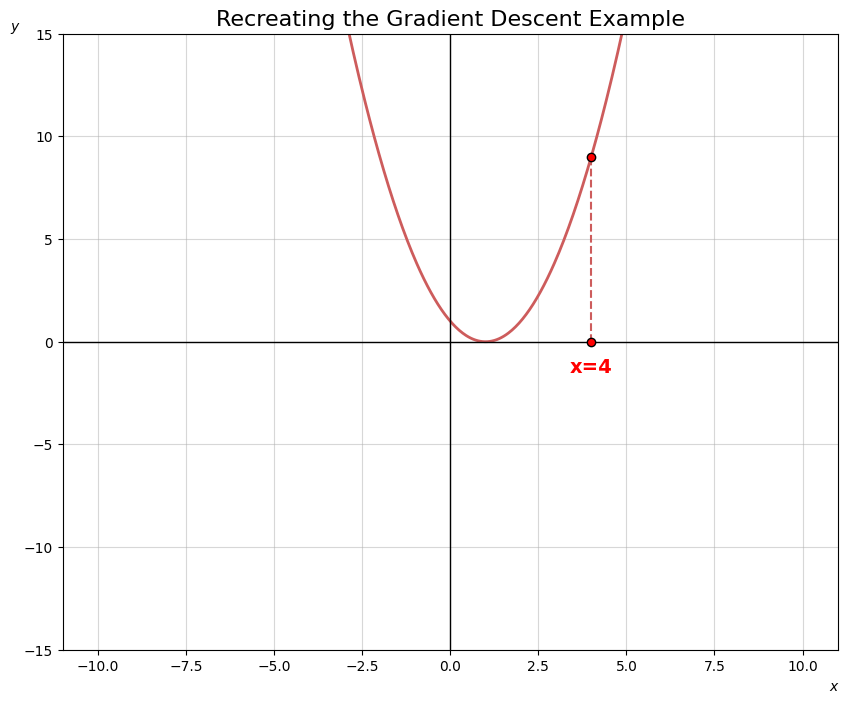

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2

# 2. Setup Data
x = np.linspace(-10, 10, 600)
y = f(x)
x_point = 4
y_point = f(x_point)

# 3. Create Plot
plt.figure(figsize=(10, 8))
plt.plot(x, y, color='indianred', linewidth=2)

# Point on the curve and on the x-axis
plt.scatter([x_point,  x_point], [y_point, 0], color='red', edgecolors='black', zorder=5)

# 4. Vertical dashed line (The 'pointer')
plt.vlines(x=x_point, ymin=0, ymax=y_point, colors='indianred', linestyles='dashed')

# 5. Labeling the x-value specifically in red
plt.text(x_point, -1.5, f'x={x_point}', color='red', fontsize=14, fontweight='bold', ha='center')

# 6. Formatting to match the image style
plt.axhline(0, color='black', linewidth=1) # X-axis
plt.axvline(0, color='black', linewidth=1) # Y-axis
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Set limits and labels
plt.xlim(-11, 11)
plt.ylim(-15, 15)
plt.xlabel('x', loc='right', fontstyle='italic')
plt.ylabel('y', loc='top', rotation=0, fontstyle='italic')

plt.title("Recreating the Gradient Descent Example", fontsize=16)
plt.show()

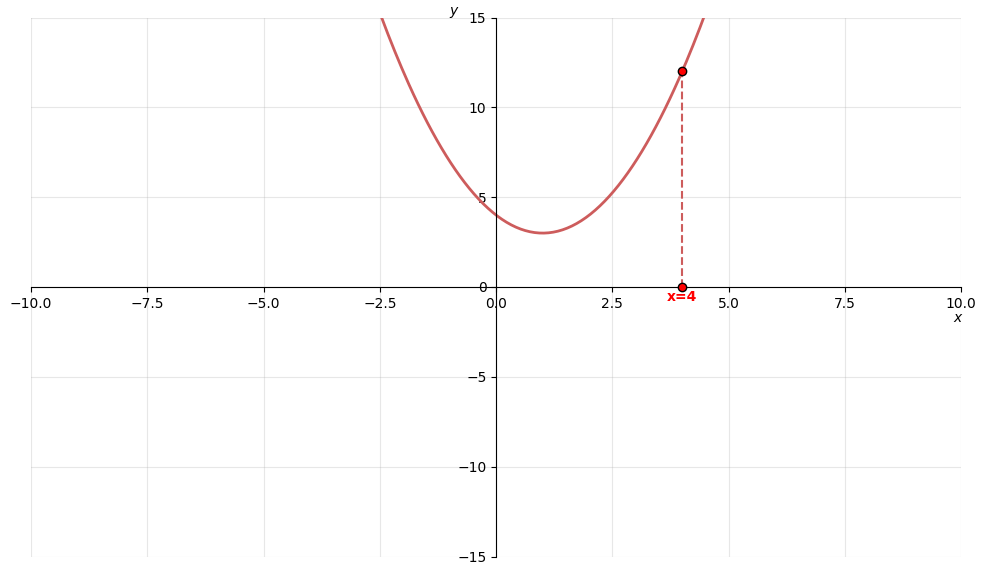

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function (as seen in image_561f24.png)
def f(x):
    return (x-1)**2 + 3

# 2. Setup Data
x = np.linspace(-10, 10, 400)
y = f(x)
x_point = 4
y_point = f(x_point)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(x, y, color='indianred', linewidth=2)

# 4. Center the Spines (This moves ticks to the axis lines)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Hide the top and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add specific markers and dashed guide line
ax.scatter([x_point, x_point], [y_point, 0], color='red', edgecolors='black', zorder=5)
ax.vlines(x=x_point, ymin=0, ymax=y_point, colors='indianred', linestyles='dashed')

# 6. Add the red x-label directly on the axis
ax.text(x_point, -0.8, f'x={x_point}', color='red', fontsize=10, fontweight='bold', ha='center')

# 7. Final Formatting
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 15)

# Labeling the actual axes
ax.set_xlabel('x', loc='right', fontstyle='italic', labelpad=0)
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic', labelpad=0)

plt.show()

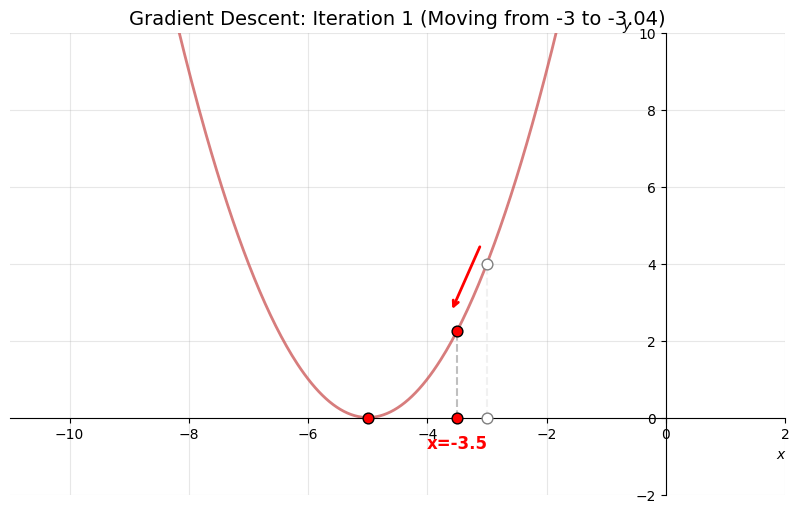

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Function and Parameters
def f(x):
    return (x - 1)**2

x_prev = -3.0
x_curr = -3.5  # Result from Iteration 1 in the image
y_prev = f(x_prev)
y_curr = f(x_curr)

# 2. Generate Curve Data
x_range = np.linspace(-10, 2, 400)
y_range = f(x_range)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, y_range, color='indianred', linewidth=2, alpha=0.8)

# 4. Center Axis Spines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Plot Points
# Previous Point: White with gray edge
ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=60, zorder=5, label='Previous')
# Current Point: Red
ax.scatter([x_curr, x_curr, -5], [y_curr, 0, 0], color='red', edgecolors='black', s=60, zorder=6, label='Current')

# 6. Add Guide Lines and Arrow
# Dashed lines for current x
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='gray', linestyles='dashed', alpha=0.5)
ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='lightgray', linestyles='dashed', alpha=0.3)

# Red Directional Arrow
ax.annotate('', xy=(x_curr - 0.1, y_curr + 0.5), xytext=(x_prev - 0.1, y_prev + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 7. Labels and Formatting
ax.text(x_curr, -0.8, f'x={x_curr}', color='red', fontsize=12, fontweight='bold', ha='center')
ax.set_xlim(-11, 2)
ax.set_ylim(-2, 10)
ax.grid(True, linestyle='-', alpha=0.3)

# Axis labels
ax.set_xlabel('x', loc='right', fontstyle='italic')
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic')

plt.title("Gradient Descent: Iteration 1 (Moving from -3 to -3.04)", fontsize=14)
plt.show()

In [ ]:
1.44 - 0.2*2.88

0.864

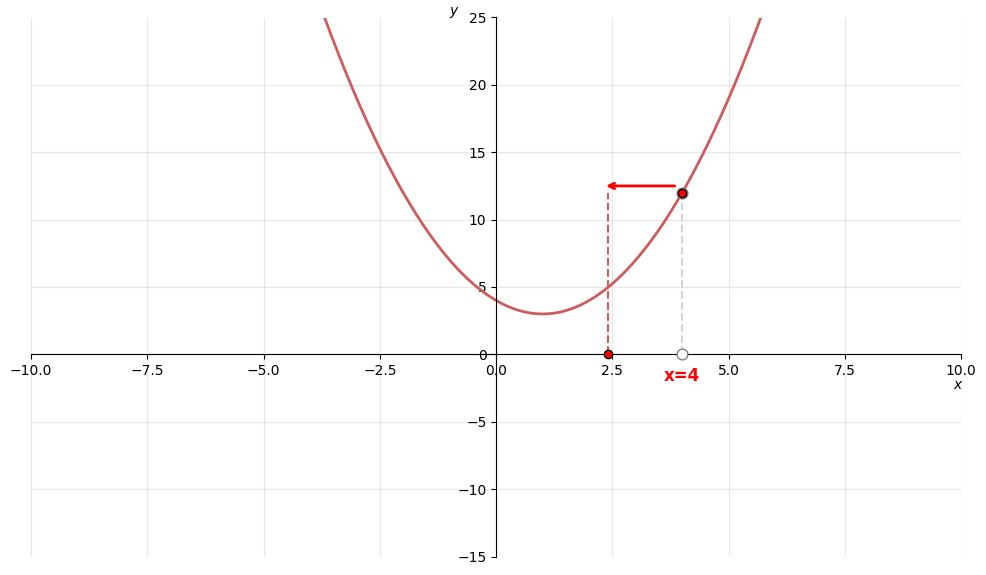

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function (as seen in image_561f24.png)
def f(x):
    return (x-1)**2 + 3

# 2. Setup Data
x = np.linspace(-10, 10, 400)
y = f(x)

x_curr = 2.4
y_curr = f(x_point)

x_prev = 4
y_prev = f(x_prev)


# 3. Create Plot
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(x, y, color='indianred', linewidth=2)

# 4. Center the Spines (This moves ticks to the axis lines)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Hide the top and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add specific markers and dashed guide line
# Previous Point: White with gray edge
ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=60, zorder=5, label='Previous')
ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='lightgray', linestyles='dashed')
# Current Point: Red with black edge
ax.scatter([x_point, x_curr], [y_curr, 0], color='red', edgecolors='black', zorder=5)
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='indianred', linestyles='dashed')

# Red Directional Arrow
ax.annotate('', xy=(x_curr - 0.1, y_curr + 0.5), xytext=(x_prev - 0.1, y_prev + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))


# 6. Add the red x-label directly on the axis
ax.text(x_point, -2, f'x={x_point}', color='red', fontsize=12, fontweight='bold', ha='center')

# 7. Final Formatting
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 25)

# Labeling the actual axes
ax.set_xlabel('x', loc='right', fontstyle='italic', labelpad=0)
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic', labelpad=0)

plt.show()

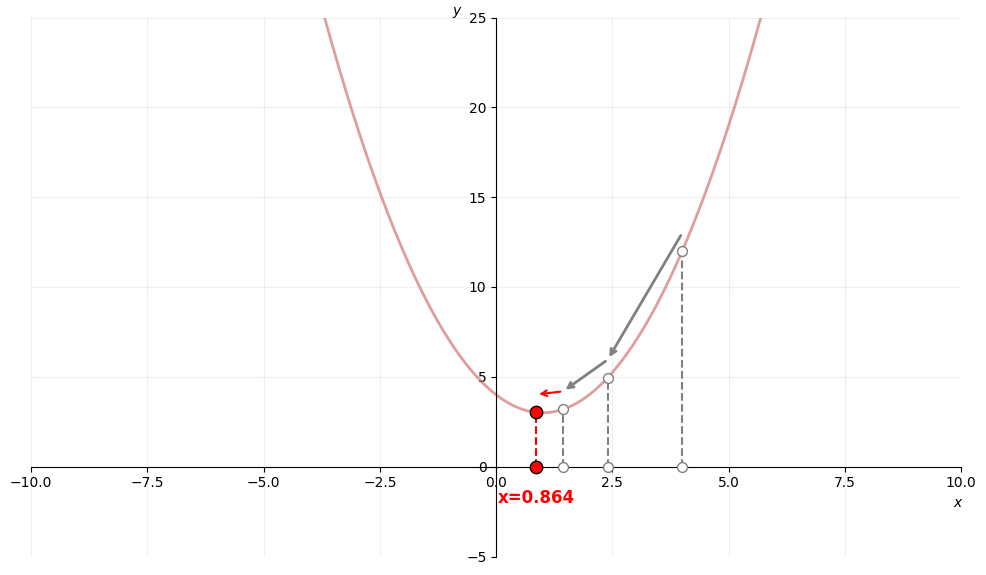

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2 + 3

# 2. Setup Data
x_range = np.linspace(-10, 10, 400)
y_vals = f(x_range)

# List of previous points (the "history")
x_history = [4, 2.4, 1.44]
# The current focal point
x_curr = 0.864
y_curr = f(x_curr)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_range, y_vals, color='indianred', linewidth=2, alpha=0.6)

# 4. Center the Spines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add Multiple Previous Points from the list
for i, x_prev in enumerate(x_history):
    y_prev = f(x_prev)
    # Plot white points with decreasing transparency (older points are lighter)
    # alpha_val = (i + 1) / len(x_history) * 0.5
    alpha_val = 1
    ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=50, zorder=4, alpha=alpha_val)
    ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='gray', linestyles='dashed', alpha=alpha_val)

    # Optional: Add arrow from this point to the next one in history
    if i < len(x_history) - 1:
        next_x = x_history[i+1]
        ax.annotate('', xy=(next_x, f(next_x) + 1), xytext=(x_prev, y_prev + 1),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=alpha_val))

# 6. Add Current Point (Red)
ax.scatter([x_curr, x_curr], [y_curr, 0], color='red', edgecolors='black', s=80, zorder=6)
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='red', linestyles='dashed', lw=1.5)

# Arrow from last history point to current point
last_x_prev = x_history[-1]
ax.annotate('', xy=(x_curr, f(x_curr) + 1), xytext=(last_x_prev, f(last_x_prev) + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# 7. Labels and Formatting
ax.text(x_curr, -2, f'x={x_curr}', color='red', fontsize=12, fontweight='bold', ha='center')
ax.grid(True, linestyle='-', alpha=0.2)
ax.set_xlim(-10, 10)
ax.set_ylim(-5, 25)

ax.set_xlabel('x', loc='right', fontstyle='italic')
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic')

# plt.title("Gradient Descent: Visualizing History with Multiple Steps")
plt.show()

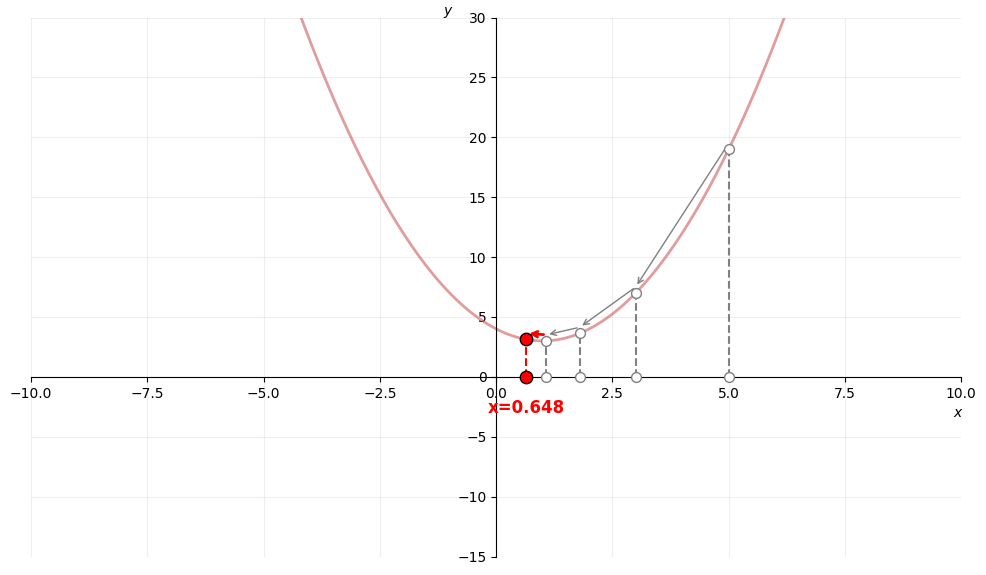

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2 + 3

# 2. Setup Data
x_range = np.linspace(-10, 10, 400)
y_vals = f(x_range)

# Single list: historical values first, last value is current
points = [5, 3, 1.8, 1.08, 0.648]
# points = [-4, -2.4, -1.44, -0.864]


# 3. Create Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_range, y_vals, color='indianred', linewidth=2, alpha=0.6)

# 4. Center the Spines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Plot Previous Points (All except the last)
history = points[:-1]
for i, x_prev in enumerate(history):
    y_prev = f(x_prev)
    # Visualizing older points as lighter (ghosting effect)
    alpha_val = 1
    ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=50, zorder=4, alpha=alpha_val)
    ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='gray', linestyles='dashed', alpha=alpha_val)

    # Arrow to the next point in the list
    next_x = points[i+1]
    # Set arrow color: red for the final jump, gray for previous steps
    is_last_jump = (i == len(history) - 1)
    arrow_col = 'red' if is_last_jump else 'gray'
    arrow_lw = 2 if is_last_jump else 1

    ax.annotate('', xy=(next_x, f(next_x) + 0.5), xytext=(x_prev, y_prev + 0.5),
                 arrowprops=dict(arrowstyle='->', color=arrow_col, lw=arrow_lw, alpha=alpha_val if not is_last_jump else 1))

# 6. Plot Current Point (The very last item in the list)
x_curr = points[-1]
y_curr = f(x_curr)

ax.scatter([x_curr, x_curr], [y_curr, 0], color='red', edgecolors='black', s=80, zorder=6)
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='red', linestyles='dashed', lw=1.5)

# 7. Labels and Formatting
ax.text(x_curr, -3, f'x={x_curr}', color='red', fontsize=12, fontweight='bold', ha='center')
ax.grid(True, linestyle='-', alpha=0.2)
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 30)

ax.set_xlabel('x', loc='right', fontstyle='italic')
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic')

# plt.title("Gradient Descent: Consolidated List Visualization")
plt.show()

In [ ]:
5 - 0.4*5

3.0

In [ ]:
3 - 0.4*3

1.7999999999999998

In [ ]:
1.8 - 0.4*1.8

1.08

In [ ]:
1.08  - 0.4* 1.08

0.648

In [ ]:
-5 + 0.4*5

-3.0

In [ ]:
-3 + 0.4*3

-1.7999999999999998

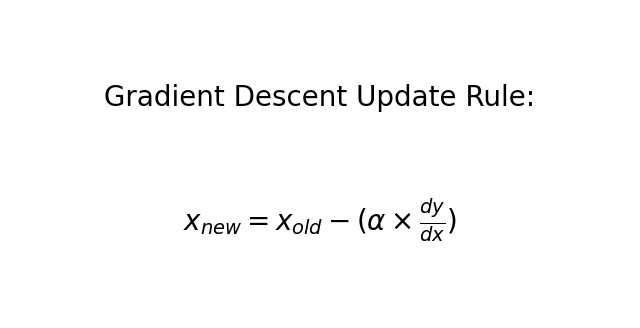

In [ ]:
# @title
import matplotlib.pyplot as plt

# 1. Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# 2. Hide all axis elements to make it look "plain"
ax.axis('off')  # This hides spines, ticks, and labels in one command

# 3. Add text and LaTeX math
# The 'r' before the string denotes a raw string for LaTeX symbols
explanation_text = (
    "Gradient Descent Update Rule:\n\n"
    r"$x_{new} = x_{old} - (\alpha \times \frac{dy}{dx})$"
)

# 4. Place the text in the center of the "plot"
ax.text(0.5, 0.5, explanation_text,
        fontsize=20,
        color='black',
        ha='center',
        va='center',
        linespacing=2)

plt.show()

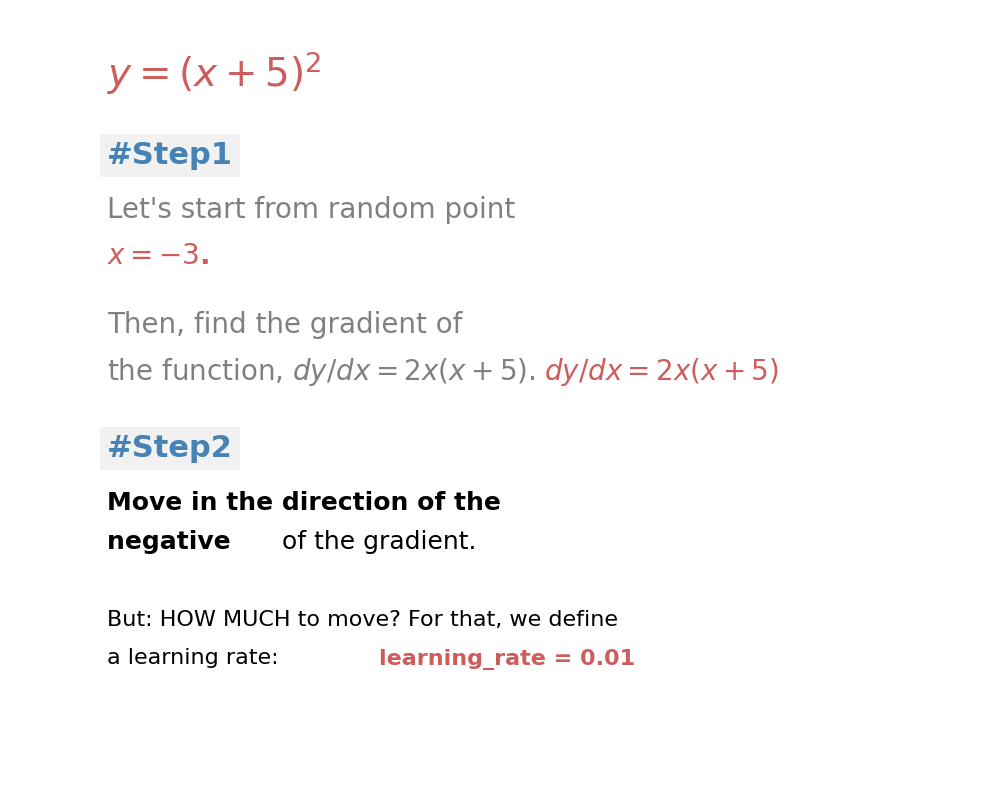

In [ ]:
# @title
import matplotlib.pyplot as plt

# 1. Setup the figure
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Hide all axis elements
ax.axis('off')

# 3. Define the content and styling
# Coordinates are (x, y) starting from bottom-left (0,0)
# We move from top to bottom (y=0.9 down to y=0.1)

# Main Function
ax.text(0.1, 0.9, r'$y=(x+5)^2$', color='indianred', fontsize=28, fontweight='bold')

# #Step1 Header with gray background
ax.text(0.1, 0.8, '#Step1', color='steelblue', fontsize=22, fontweight='bold',
        bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))

# Step 1 Body
ax.text(0.1, 0.73, "Let's start from random point", color='gray', fontsize=20)
ax.text(0.1, 0.67, r'$x=-3$.', color='indianred', fontsize=20, fontweight='bold')

ax.text(0.1, 0.58, "Then, find the gradient of", color='gray', fontsize=20)
ax.text(0.1, 0.52, r'the function, $dy/dx = 2x(x+5)$.', color='gray', fontsize=20)
# Highlighted part of the gradient
ax.text(0.55, 0.52, r'$dy/dx = 2x(x+5)$', color='indianred', fontsize=20)

# #Step2 Header
ax.text(0.1, 0.42, '#Step2', color='steelblue', fontsize=22, fontweight='bold',
        bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))

# Step 2 Body
ax.text(0.1, 0.35, "Move in the direction of the ", color='black', fontsize=18, fontweight='bold')
ax.text(0.1, 0.30, "negative ", color='black', fontsize=18, fontweight='bold')
ax.text(0.28, 0.30, "of the gradient.", color='black', fontsize=18)

ax.text(0.1, 0.20, "But: HOW MUCH to move? For that, we define", color='black', fontsize=16)
ax.text(0.1, 0.15, "a learning rate: ", color='black', fontsize=16)
ax.text(0.38, 0.15, "learning_rate = 0.01", color='indianred', fontsize=16, fontweight='bold')

# 4. Show the "document"
plt.tight_layout()
plt.show()

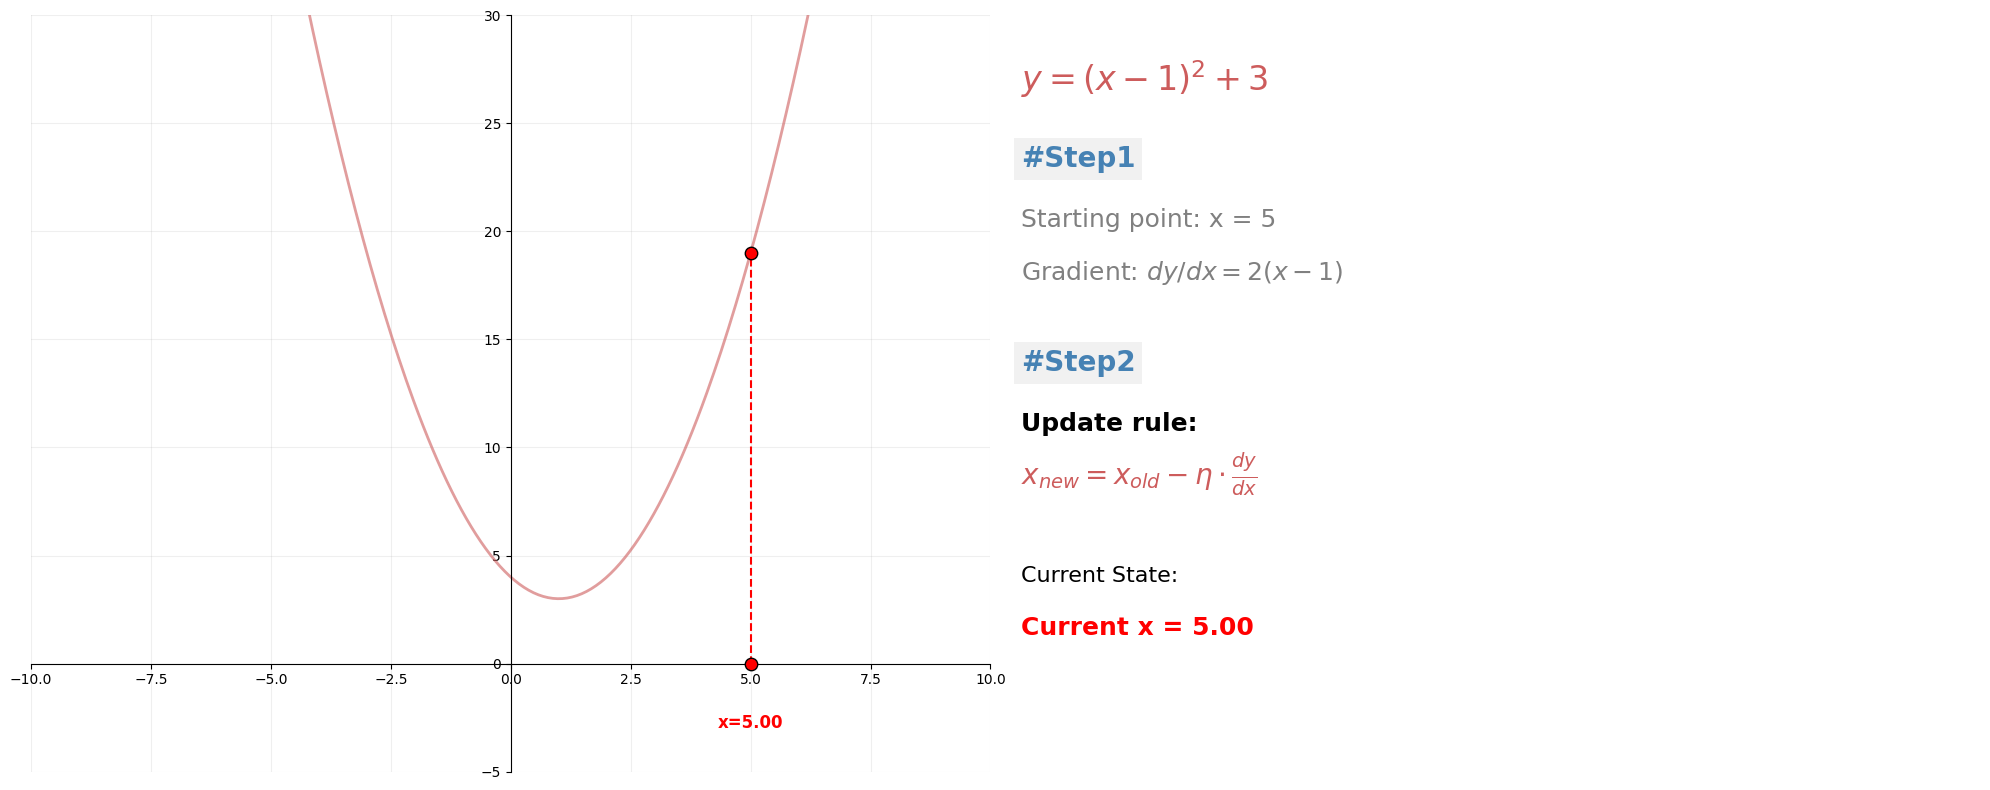

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2 + 3

# 2. Setup Data
x_range = np.linspace(-10, 10, 400)
y_vals = f(x_range)
# points = [5, 3.4, 2.44, 1.86, 1.51] # Example history
points = [5]

# 3. Create Subplots (1 row, 2 columns)
fig, (ax_plot, ax_text) = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT PLOT: THE GRAPH ---
ax_plot.plot(x_range, y_vals, color='indianred', linewidth=2, alpha=0.6)
ax_plot.spines['left'].set_position('zero')
ax_plot.spines['bottom'].set_position('zero')
ax_plot.spines['right'].set_color('none')
ax_plot.spines['top'].set_color('none')

# Plot History and Current Point
history = points[:-1]
for i, x_prev in enumerate(history):
    y_prev = f(x_prev)
    ax_plot.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=50, zorder=4)
    ax_plot.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='gray', linestyles='dashed', alpha=0.5)

    next_x = points[i+1]
    is_last = (i == len(history) - 1)
    ax_plot.annotate('', xy=(next_x, f(next_x) + 0.5), xytext=(x_prev, y_prev + 0.5),
                     arrowprops=dict(arrowstyle='->', color='red' if is_last else 'gray', lw=2 if is_last else 1))

x_curr = points[-1]
ax_plot.scatter([x_curr, x_curr], [f(x_curr), 0], color='red', edgecolors='black', s=80, zorder=6)
ax_plot.vlines(x=x_curr, ymin=0, ymax=f(x_curr), colors='red', linestyles='dashed', lw=1.5)
ax_plot.text(x_curr, -3, f'x={x_curr:.2f}', color='red', fontsize=12, fontweight='bold', ha='center')

ax_plot.set_xlim(-10, 10)
ax_plot.set_ylim(-5, 30)
ax_plot.grid(True, linestyle='-', alpha=0.2)

# --- RIGHT PLOT: THE PLAIN TEXT ---
ax_text.axis('off')

# Adding the structured text from the image example
ax_text.text(0.0, 0.9, r'$y=(x-1)^2 + 3$', color='indianred', fontsize=24, fontweight='bold')

# Step 1 highlight
ax_text.text(0.0, 0.8, '#Step1', color='steelblue', fontsize=20, fontweight='bold',
             bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
ax_text.text(0.0, 0.72, f"Starting point: x = {points[0]}", color='gray', fontsize=18)
ax_text.text(0.0, 0.65, r"Gradient: $dy/dx = 2(x-1)$", color='gray', fontsize=18)

# Step 2 highlight
ax_text.text(0.0, 0.53, '#Step2', color='steelblue', fontsize=20, fontweight='bold',
             bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))



ax_text.text(0.0, 0.45, "Update rule:", color='black', fontsize=18, fontweight='bold')
ax_text.text(0.0, 0.38, r"$x_{new} = x_{old} - \eta \cdot \frac{dy}{dx}$", color='indianred', fontsize=20)

ax_text.text(0.0, 0.25, "Current State:", color='black', fontsize=16)
ax_text.text(0.0, 0.18, f"Current x = {x_curr:.2f}", color='red', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

<>:74: SyntaxWarning: invalid escape sequence '\e'
<>:74: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2658/1670582295.py:74: SyntaxWarning: invalid escape sequence '\e'
  ax.text(0.0, 0.25, f"Learning Rate ($\eta$): {learning_rate}", color='black', fontsize=14)


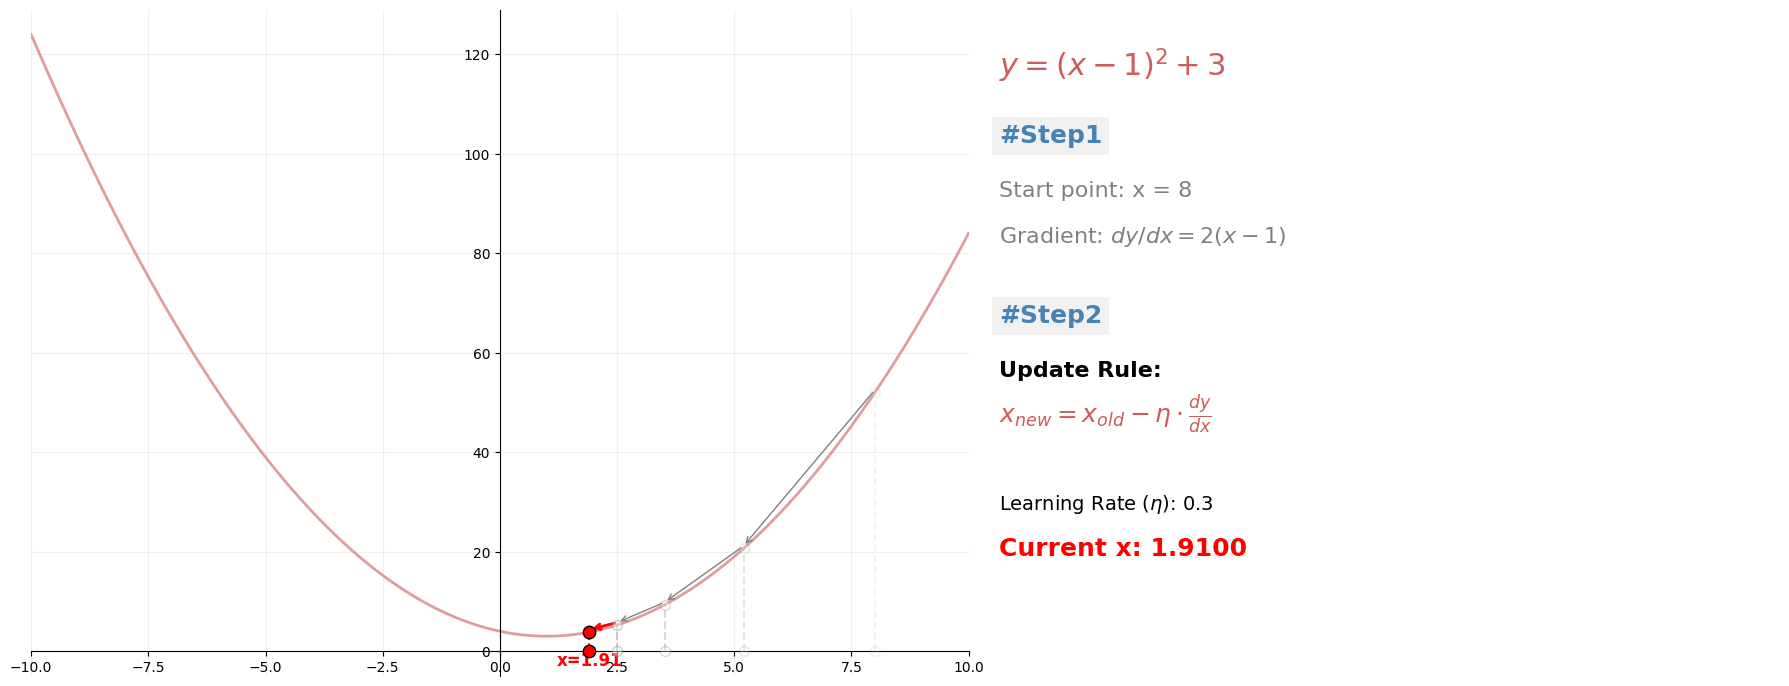

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Mathematical Logic
def f(x):
    return (x - 1)**2 + 3

def df(x):
    """Derivative of the function for the text display."""
    return 2 * (x - 1)

# 2. Reusable Function for the Graph
def plot_gradient_descent_evolution(ax, history, x_range_vals):
    # Plot the main curve
    y_vals = f(x_range_vals)
    ax.plot(x_range_vals, y_vals, color='indianred', linewidth=2, alpha=0.6)

    # Configure centered axes (spines)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # Separate history from current
    history_points = history[:-1]
    x_curr = history[-1]

    # Plot Previous Steps (History)
    for i, x_prev in enumerate(history_points):
        y_prev = f(x_prev)
        # Fade older points more
        alpha_val = (i + 1) / (len(history_points) + 1) * 0.5

        ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=50, zorder=4, alpha=alpha_val)
        ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='gray', linestyles='dashed', alpha=alpha_val)

        # Draw connecting arrows
        next_x = history[i+1]
        is_last_jump = (next_x == x_curr)
        arrow_col = 'red' if is_last_jump else 'gray'
        ax.annotate('', xy=(next_x, f(next_x) + 0.5), xytext=(x_prev, y_prev + 0.5),
                     arrowprops=dict(arrowstyle='->', color=arrow_col, lw=2 if is_last_jump else 1))

    # Plot Current Point (Highlighted)
    ax.scatter([x_curr, x_curr], [f(x_curr), 0], color='red', edgecolors='black', s=80, zorder=6)
    ax.vlines(x=x_curr, ymin=0, ymax=f(x_curr), colors='red', linestyles='dashed', lw=1.5)
    ax.text(x_curr, -3, f'x={x_curr:.2f}', color='red', fontsize=12, fontweight='bold', ha='center')

    # General Formatting
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_xlim(min(x_range_vals), max(x_range_vals))
    ax.set_ylim(-5, max(y_vals) + 5)

# 3. Reusable Function for the Explanation Text
def plot_explanation_text(ax, x_start, x_curr, learning_rate):
    ax.axis('off')

    # Header & Equation
    ax.text(0.0, 0.9, r'$y = (x - 1)^2 + 3$', color='indianred', fontsize=22, fontweight='bold')

    # Step 1
    ax.text(0.0, 0.8, '#Step1', color='steelblue', fontsize=18, fontweight='bold',
             bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
    ax.text(0.0, 0.72, f"Start point: x = {x_start}", color='gray', fontsize=16)
    ax.text(0.0, 0.65, r"Gradient: $dy/dx = 2(x-1)$", color='gray', fontsize=16)

    # Step 2
    ax.text(0.0, 0.53, '#Step2', color='steelblue', fontsize=18, fontweight='bold',
             bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
    ax.text(0.0, 0.45, "Update Rule:", color='black', fontsize=16, fontweight='bold')
    ax.text(0.0, 0.38, r"$x_{new} = x_{old} - \eta \cdot \frac{dy}{dx}$", color='indianred', fontsize=18)

    # Parameters
    ax.text(0.0, 0.25, f"Learning Rate ($\eta$): {learning_rate}", color='black', fontsize=14)
    ax.text(0.0, 0.18, f"Current x: {x_curr:.4f}", color='red', fontsize=18, fontweight='bold')

# 4. Main Execution
if __name__ == "__main__":
    # Configuration
    my_history = [8, 5.2, 3.52, 2.51, 1.91] # Last value is always current
    x_view = np.linspace(-10, 10, 400)
    lr = 0.3

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.2, 1]})

    plot_gradient_descent_evolution(ax1, my_history, x_view)
    plot_explanation_text(ax2, my_history[0], my_history[-1], lr)

    plt.tight_layout()
    plt.show()

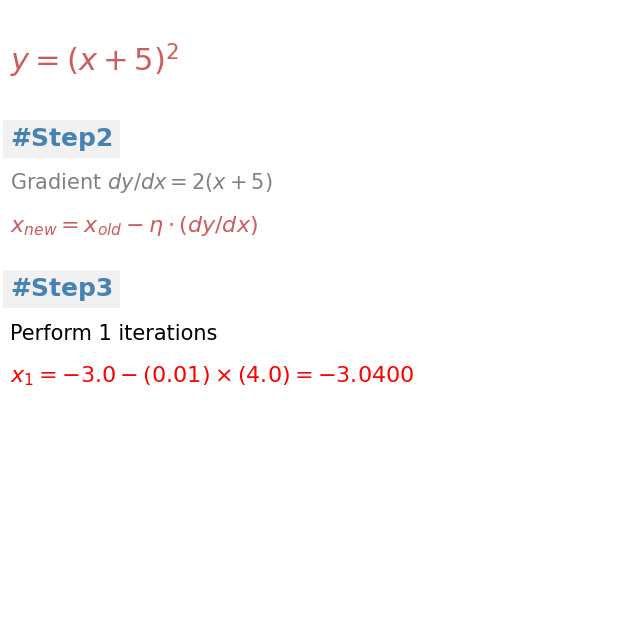

In [ ]:
# @title
import matplotlib.pyplot as plt

def plot_dynamic_text(ax, steps_to_show, current_x, x_history, lr):
    """
    ax: The matplotlib axis to draw on
    steps_to_show: List of integers, e.g., [1, 2] or [3]
    current_x: The most recent x value
    x_history: The list of previous x values
    lr: The learning rate
    """
    ax.axis('off')

    # Starting vertical position
    y_pos = 0.9
    line_height = 0.07

    # Static Header: Always show the function
    ax.text(0.0, y_pos, r'$y = (x+5)^2$', color='indianred', fontsize=22, fontweight='bold')
    y_pos -= 0.12

    # --- STEP 1: Initialization ---
    if 1 in steps_to_show:
        ax.text(0.0, y_pos, '#Step1', color='steelblue', fontsize=18, fontweight='bold',
                 bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
        y_pos -= line_height
        ax.text(0.0, y_pos, f"Start at random point x = {x_history[0]}", color='gray', fontsize=15)
        y_pos -= line_height * 1.5 # Extra gap between steps

    # --- STEP 2: The Logic ---
    if 2 in steps_to_show:
        ax.text(0.0, y_pos, '#Step2', color='steelblue', fontsize=18, fontweight='bold',
                 bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
        y_pos -= line_height
        ax.text(0.0, y_pos, r"Gradient $dy/dx = 2(x+5)$", color='gray', fontsize=15)
        y_pos -= line_height
        ax.text(0.0, y_pos, r"$x_{new} = x_{old} - \eta \cdot (dy/dx)$", color='indianred', fontsize=16)
        y_pos -= line_height * 1.5

    # --- STEP 3: Iteration Details ---
    if 3 in steps_to_show:
        ax.text(0.0, y_pos, '#Step3', color='steelblue', fontsize=18, fontweight='bold',
                 bbox=dict(facecolor='lightgray', alpha=0.3, edgecolor='none', pad=5))
        y_pos -= line_height
        ax.text(0.0, y_pos, f"Perform {len(x_history)} iterations", color='black', fontsize=15)
        y_pos -= line_height

        # Display the math for the most recent iteration
        x_old = x_history[-1] if len(x_history) > 0 else x_history[0]
        grad = 2 * (x_old + 5)
        math_str = fr"$x_1 = {x_old} - ({lr}) \times ({grad}) = {current_x:.4f}$"
        ax.text(0.0, y_pos, math_str, color='red', fontsize=16, fontweight='bold')

# --- Example Usage ---
fig, ax = plt.subplots(figsize=(8, 8))

# Change this list to [1], [1, 2], [3], or [1, 2, 3] to see it update
steps = [ 2, 3]

plot_dynamic_text(ax,
                  steps_to_show=steps,
                  current_x=-3.04,
                  x_history=[-3.0],
                  lr=0.01)

plt.show()

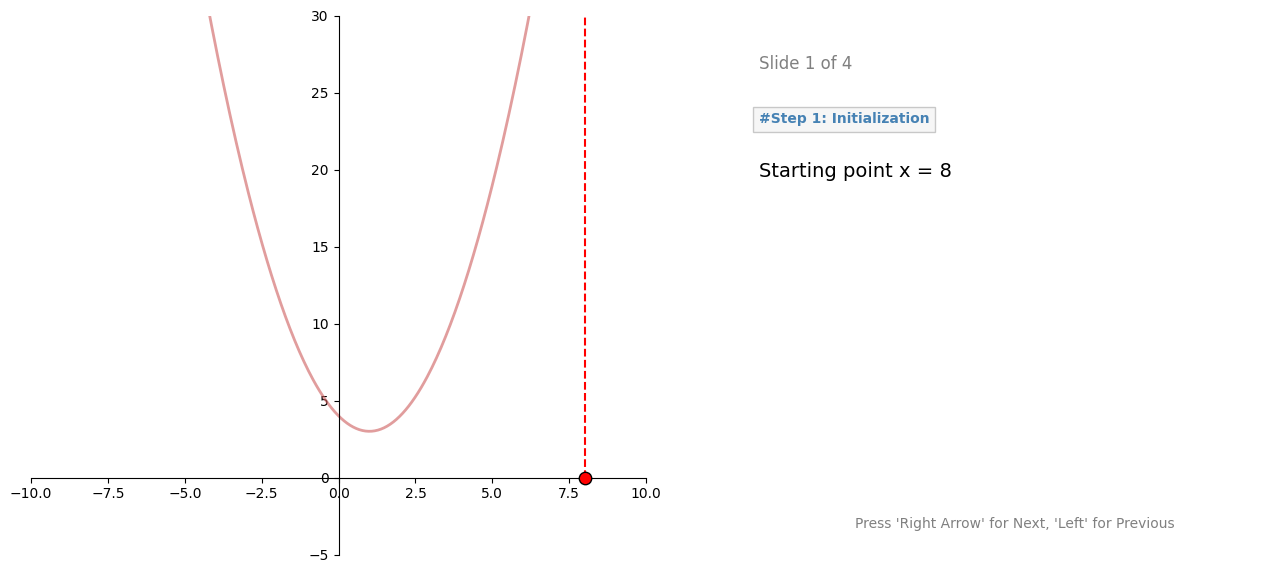

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration & Data
def f(x): return (x - 1)**2 + 3

x_range = np.linspace(-10, 10, 400)
# Define the sequence of points (The "Slides")
slides_history = [
    [8],              # Slide 0: Start
    [8, 5.2],         # Slide 1: First Step
    [8, 5.2, 3.5],    # Slide 2: Second Step
    [8, 5.2, 3.5, 2.5]# Slide 3: Final state
]
current_slide = 0

# 2. Functional Plotting Components
def draw_graph(ax, history):
    ax.clear()
    ax.plot(x_range, f(x_range), color='indianred', linewidth=2, alpha=0.6)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # Plot history (white dots) and current (red dot)
    for i, x_p in enumerate(history[:-1]):
        ax.scatter([x_p, x_p], [f(x_p), 0], color='white', edgecolors='gray', zorder=4)
        ax.annotate('', xy=(history[i+1], f(history[i+1])), xytext=(x_p, f(x_p)),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    x_curr = history[-1]
    ax.scatter([x_curr, x_curr], [f(x_curr), 0], color='red', edgecolors='black', s=80, zorder=6)
    ax.vlines(x=x_curr, ymin=0, ymax=f(x_curr), colors='red', linestyles='dashed')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-5, 30)

def draw_text(ax, slide_idx):
    ax.clear()
    ax.axis('off')
    y = 0.9
    ax.text(0, y, f"Slide {slide_idx + 1} of {len(slides_history)}", fontsize=12, color='gray')
    y -= 0.1

    # Logic to show specific steps based on slide index
    if slide_idx >= 0:
        ax.text(0, y, "#Step 1: Initialization", fontweight='bold', color='steelblue', bbox=dict(facecolor='lightgray', alpha=0.2))
        y -= 0.1
        ax.text(0, y, f"Starting point x = {slides_history[0][0]}", fontsize=14)

    if slide_idx >= 1:
        y -= 0.15
        ax.text(0, y, "#Step 2: Iterating...", fontweight='bold', color='steelblue', bbox=dict(facecolor='lightgray', alpha=0.2))
        y -= 0.1
        curr_x = slides_history[slide_idx][-1]
        ax.text(0, y, f"Current position: {curr_x:.2f}", fontsize=16, color='red')

    ax.text(0.5, 0.05, "Press 'Right Arrow' for Next, 'Left' for Previous", fontsize=10, ha='center', color='gray')

# 3. Animation Controller
def on_press(event):
    global current_slide
    if event.key == 'right':
        current_slide = min(current_slide + 1, len(slides_history) - 1)
    elif event.key == 'left':
        current_slide = max(current_slide - 1, 0)

    update_display()

def update_display():
    draw_graph(ax1, slides_history[current_slide])
    draw_text(ax2, current_slide)
    fig.canvas.draw()

# 4. Initialize Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.2, 1]})
fig.canvas.mpl_connect('key_press_event', on_press)

update_display()
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import widgets, HBox
from IPython.display import display, clear_output

# 1. Configuration & Data
def f(x): return (x - 1)**2 + 3

x_range = np.linspace(-10, 10, 400)
# Define your steps/slides here
slides_history = [
    [8],              # Slide 0
    [8, 5.2],         # Slide 1
    [8, 5.2, 3.5],    # Slide 2
    [8, 5.2, 3.5, 2.5]# Slide 3
]

class GradientSlides:
    def __init__(self):
        self.current_slide = 0
        self.out = widgets.Output()

        # Define Buttons
        self.btn_prev = widgets.Button(description="Previous", icon="arrow-left")
        self.btn_next = widgets.Button(description="Next", icon="arrow-right")

        # Assign Clicks
        self.btn_prev.on_click(self.prev_slide)
        self.btn_next.on_click(self.next_slide)

        # Display everything
        display(HBox([self.btn_prev, self.btn_next]), self.out)
        self.update_display()

    def draw_content(self, ax_plot, ax_text, slide_idx):
        history = slides_history[slide_idx]
        x_curr = history[-1]

        # --- LEFT: GRAPH ---
        ax_plot.plot(x_range, f(x_range), color='indianred', linewidth=2, alpha=0.6)
        ax_plot.spines['left'].set_position('zero')
        ax_plot.spines['bottom'].set_position('zero')
        ax_plot.spines['right'].set_color('none')
        ax_plot.spines['top'].set_color('none')

        for i, x_p in enumerate(history[:-1]):
            ax_plot.scatter([x_p, x_p], [f(x_p), 0], color='white', edgecolors='gray', zorder=4)
            next_x = history[i+1]
            ax_plot.annotate('', xy=(next_x, f(next_x)), xytext=(x_p, f(x_p)),
                             arrowprops=dict(arrowstyle='->', color='gray', lw=1))

        ax_plot.scatter([x_curr, x_curr], [f(x_curr), 0], color='red', edgecolors='black', s=80, zorder=6)
        ax_plot.vlines(x=x_curr, ymin=0, ymax=f(x_curr), colors='red', linestyles='dashed')
        ax_plot.set_xlim(-10, 10)
        ax_plot.set_ylim(-5, 30)

        # --- RIGHT: TEXT ---
        ax_text.axis('off')
        y = 0.9
        ax_text.text(0, y, f"Slide {slide_idx + 1} of {len(slides_history)}", color='gray')

        # Example of conditional step showing
        if slide_idx >= 0:
            y -= 0.15
            ax_text.text(0, y, "#Step 1: Initialization", fontweight='bold', color='steelblue',
                         bbox=dict(facecolor='lightgray', alpha=0.2))
            y -= 0.1
            ax_text.text(0, y, f"Start point x = {slides_history[0][0]}", fontsize=12)

        if slide_idx >= 1:
            y -= 0.2
            ax_text.text(0, y, "#Step 2: Update", fontweight='bold', color='steelblue',
                         bbox=dict(facecolor='lightgray', alpha=0.2))
            y -= 0.1
            ax_text.text(0, y, f"Current x = {x_curr:.2f}", fontsize=14, color='red')

    def update_display(self):
        with self.out:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.2, 1]})
            self.draw_content(ax1, ax2, self.current_slide)
            plt.show()

    def next_slide(self, b):
        if self.current_slide < len(slides_history) - 1:
            self.current_slide += 1
            self.update_display()

    def prev_slide(self, b):
        if self.current_slide > 0:
            self.current_slide -= 1
            self.update_display()

# Launch the interactive slides
GradientSlides()

Output()